In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

Load and inspect data

In [3]:
data = pd.read_csv('data.csv', encoding='latin-1')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


(541909, 8)

Assign accurate datatypes to the columns

In [5]:
data['InvoiceDate'] = data['InvoiceDate'].astype('datetime64[ns]')
data['Country'] = data['Country'].astype('string')
data['Description'] = data['Description'].astype('string')


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  string        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  string        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2), string(2)
memory usage: 33.1+ MB


Checking for missing values and handling it.

In [7]:
data.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [8]:
data.fillna({'CustomerID': data['CustomerID'].mean()}, inplace=True)


In [9]:
data['Description'] = data['Description'].bfill()
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Final inspection before analysis

In [10]:
data.describe().round(2)

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.00,541909,541909.00,541909.00
mean,9.55,2011-07-04 13:34:57.156386048,4.61,15287.69
min,-80995.00,2010-12-01 08:26:00,-11062.06,12346.00
25%,1.00,2011-03-28 11:34:00,1.25,14367.00
50%,3.00,2011-07-19 17:17:00,2.08,15287.69
75%,10.00,2011-10-19 11:27:00,4.13,16255.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,218.08,NaN,96.76,1484.75


Revenue & Sales Performance <br>
Business problem:<br>
Helps the business plan inventory, marketing budgets, and staffing around peak seasons.<br>
<b>Q1. Which months generated the highest revenue and is there a seasonal pattern?</b>


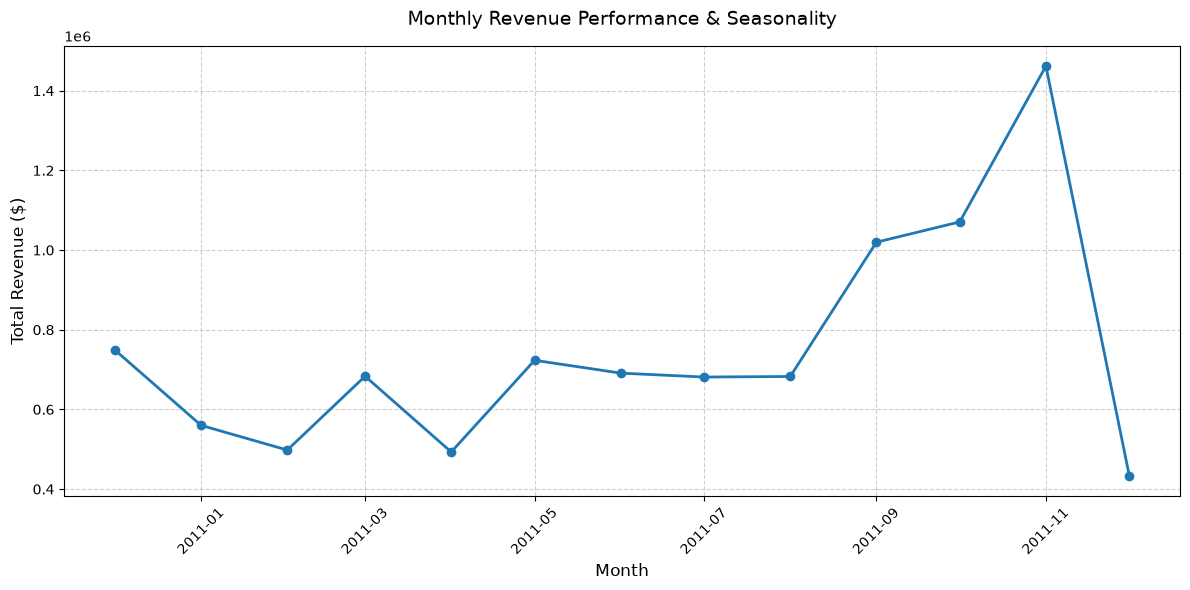

    YearMonth   TotalPrice
11 2011-11-01  1461756.250
10 2011-10-01  1070704.670
9  2011-09-01  1019687.622
0  2010-12-01   748957.020
5  2011-05-01   723333.510
6  2011-06-01   691123.120
3  2011-03-01   683267.080
8  2011-08-01   682680.510
7  2011-07-01   681300.111
1  2011-01-01   560000.260
2  2011-02-01   498062.650
4  2011-04-01   493207.121
12 2011-12-01   433668.010


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Engineer the TotalPrice column (Quantity x UnitPrice)
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

# 2. Extract Year and Month as a period for chronological sorting
data["YearMonth"] = data["InvoiceDate"].dt.to_period("M")

# 3. Group by the month and sum the revenue
monthly_revenue = (
    data.groupby("YearMonth")["TotalPrice"].sum().reset_index()
)

# Convert YearMonth back to timestamp for clean plotting
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].dt.to_timestamp()

# 4. Plot the time-series line chart
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["TotalPrice"],
    marker="o",
    linewidth=2,
    color="#1f77b4",
)

# Formatting the chart
plt.title("Monthly Revenue Performance & Seasonality", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

# 5. Optional: Print the raw numbers to easily identify the peak month
print(monthly_revenue.sort_values(by="TotalPrice", ascending=False))


Business problem:<br> 
Informs product listing decisions promote winners, review or discontinue losers.<br>
<b> Q2. Which are the top 10 products by total revenue, and which products are consistently underperforming?</b>

Top 10 Products by Revenue:
     StockCode                         Description  TotalPrice
6185       DOT                      DOTCOM POSTAGE   206245.48
2108     22423            REGENCY CAKESTAND 3 TIER   164762.19
4186     47566                       PARTY BUNTING    98302.98
5524    85123A  WHITE HANGING HEART T-LIGHT HOLDER    97715.99
5489    85099B             JUMBO BAG RED RETROSPOT    92356.03
3052     23084                  RABBIT NIGHT LIGHT    66756.59
6191      POST                             POSTAGE    66230.64
1696     22086     PAPER CHAIN KIT 50'S CHRISTMAS     63791.94
5145     84879       ASSORTED COLOUR BIRD ORNAMENT    58959.73
4504     79321                       CHILLI LIGHTS    53768.06


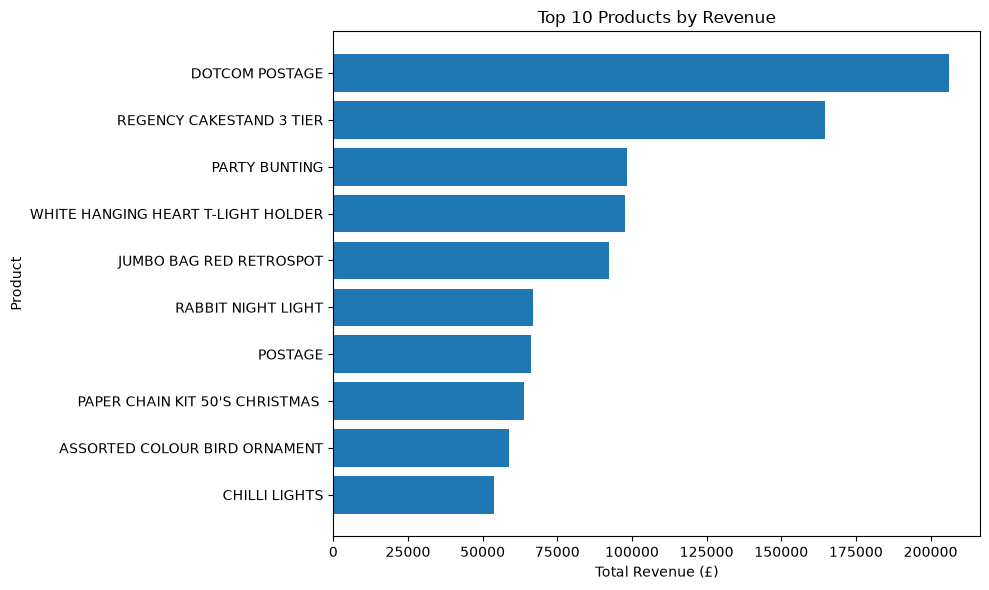


Bottom 10 Products by Revenue:
         StockCode                     Description  TotalPrice
6158     AMAZONFEE                      AMAZON FEE -221520.500
6186             M                          Manual  -68674.190
6159             B                 Adjust bad debt  -11062.060
6163          CRUK                 CRUK Commission   -7933.430
6160  BANK CHARGES                    Bank Charges   -7175.639
6164             D                        Discount   -5696.220
6193             S                         SAMPLES   -3049.390
4515        79323W             WHITE CHERRY LIGHTS     -54.000
5451         85063  CREAM SWEETHEART MAGAZINE RACK     -46.850
3801         35400     WOODEN BOX ADVENT CALENDAR      -45.700


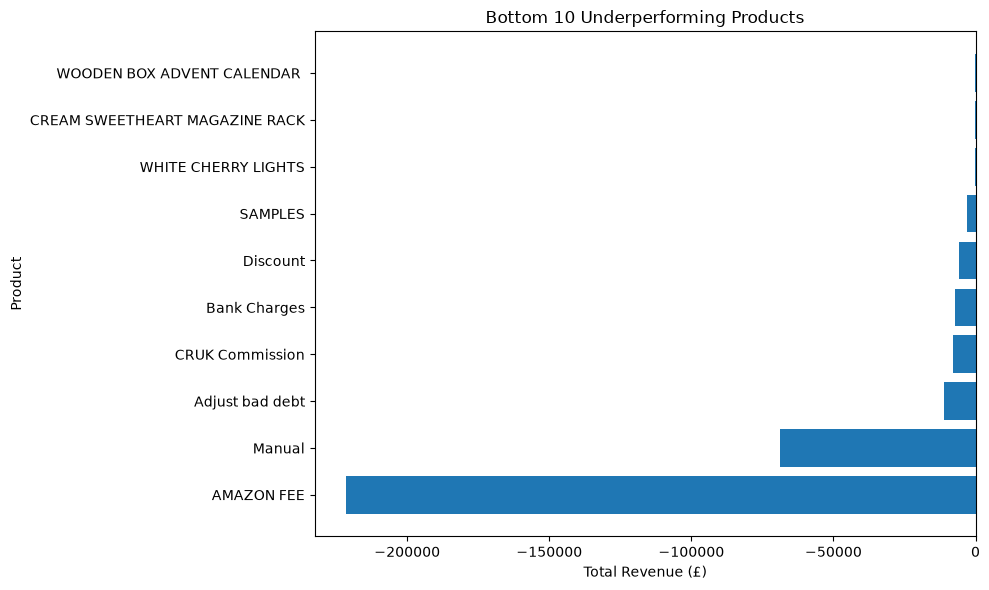

In [12]:
# Create TotalPrice if it doesn't exist
# if 'TotalPrice' not in data.columns:
#     data['TotalPrice'] = data['Quantity'] * data['UnitPrice']


# Top 10 Products by Total Revenue
top_products = (
    data.groupby(['StockCode', 'Description'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values(by='TotalPrice', ascending=False)
    .head(10)
)

print("Top 10 Products by Revenue:")
print(top_products)

# Plot Top 10 Products
plt.figure(figsize=(10, 6))
plt.barh(
    top_products['Description'],
    top_products['TotalPrice']
)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.title('Top 10 Products by Revenue')
plt.gca().invert_yaxis()  # Highest revenue on top
plt.tight_layout()
plt.show()

# Bottom 10 Products by Total Revenue
bottom_products = (
    data.groupby(['StockCode', 'Description'])['TotalPrice']
    .sum()
    .reset_index()
    .sort_values(by='TotalPrice', ascending=True)
    .head(10)
)



print("\nBottom 10 Products by Revenue:")
print(bottom_products)

# Plot Bottom 10 Products
plt.figure(figsize=(10, 6))
plt.barh(
    bottom_products['Description'],
    bottom_products['TotalPrice']
)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.title('Bottom 10 Underperforming Products')
plt.tight_layout()
plt.show()

Business problem:<br>
Reveals whether international expansion is worth the logistics and operational cost.<br>

<b>Q3. Which countries contribute the most to total sales, and how does the UK compare to international markets?</b>

In [13]:
# Group by country and calculate total sales
country_sales = (
    data.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Calculate percentage contribution
total_sales = country_sales['TotalPrice'].sum()
country_sales['SalesShare_%'] = (
    country_sales['TotalPrice'] / total_sales * 100
).round(2)

# Display top countries
print(country_sales.head(10))

          Country   TotalPrice  SalesShare_%
0  United Kingdom  8187806.364         84.00
1     Netherlands   284661.540          2.92
2            EIRE   263276.820          2.70
3         Germany   221698.210          2.27
4          France   197403.900          2.03
5       Australia   137077.270          1.41
6     Switzerland    56385.350          0.58
7           Spain    54774.580          0.56
8         Belgium    40910.960          0.42
9          Sweden    36595.910          0.38


In [14]:
# UK sales
uk_sales = country_sales.loc[
    country_sales['Country'] == 'United Kingdom',
    'TotalPrice'
].sum()

# Non-UK sales
international_sales = total_sales - uk_sales

# Percentage shares
uk_share = (uk_sales / total_sales) * 100
international_share = (international_sales / total_sales) * 100

print(f"UK Sales: £{uk_sales:,.2f}")
print(f"International Sales: £{international_sales:,.2f}")
print(f"UK Share: {uk_share:.2f}%")
print(f"International Share: {international_share:.2f}%")

UK Sales: £8,187,806.36
International Sales: £1,559,941.57
UK Share: 84.00%
International Share: 16.00%


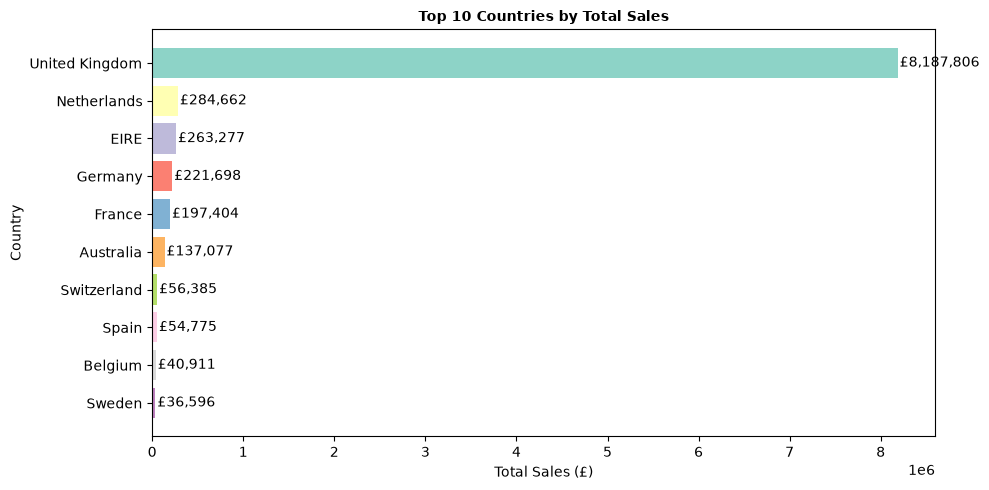

In [15]:
# Top 10 countries
top_10 = country_sales.head(10)

plt.figure(figsize=(10, 5))

# Colorful bars
colors = plt.cm.Set3(range(len(top_10)))

bars = plt.barh(
    top_10['Country'],
    top_10['TotalPrice'],
    color=colors
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_width() + 20000,
        bar.get_y() + bar.get_height()/2,
        f'£{bar.get_width():,.0f}',
        va='center',
        fontsize=10
    )

plt.title('Top 10 Countries by Total Sales', fontsize=10, fontweight='bold')
plt.xlabel('Total Sales (£)')
plt.ylabel('Country')

# Highest value on top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


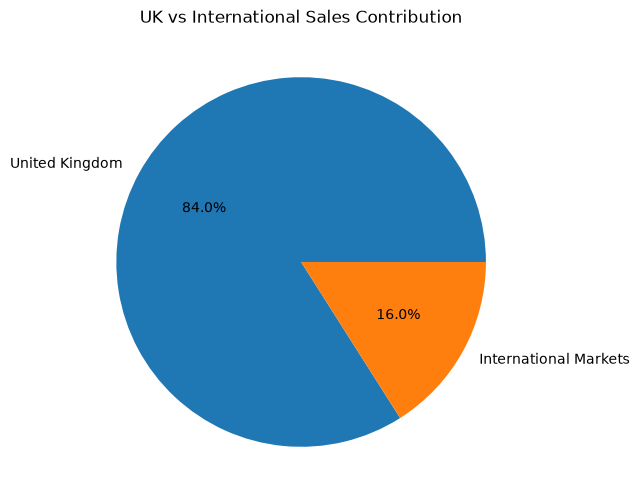

In [16]:
plt.figure(figsize=(6, 6))

plt.pie(
    [uk_sales, international_sales],
    labels=['United Kingdom', 'International Markets'],
    autopct='%1.1f%%',
)

plt.title('UK vs International Sales Contribution')
plt.show()

Area 2 Customer Behaviour <br>
<b>Business context:</b><br>
RFM segmentation lets the marketing team personalise campaigns, reward Champions and win back At-Risk customers.<br>
<b>Q4. Who are our most valuable customers, and who is at risk of churning?</b>

In [17]:
# Step 01. Calculate RFM Metrics

# Reference date (1 day after last transaction)
snapshot_date = data['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics
rfm = data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalPrice': 'sum'                                       # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Preview
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [18]:
# Step 02. Create RFM Scores (1–5)tep 02. RFM Segmentation
# Recency Score
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    q=5,
    labels=[5,4,3,2,1]
)

# Frequency Score
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=5,
    labels=[1,2,3,4,5]
)

# Monetary Score
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    q=5,
    labels=[1,2,3,4,5]
)

# Convert to integers
rfm[['R_Score','F_Score','M_Score']] = (
    rfm[['R_Score','F_Score','M_Score']]
    .astype(int)
)

rfm.head()


,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,2,0.00,1,2,1
12347.0,2,7,4310.00,5,4,5
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,4,1,4
12350.0,310,1,334.40,1,1,2


In [19]:
# Step 03 Step 3: Calculate Overall RFM Score
rfm['RFM_Score'] = (
    rfm['R_Score'] +
    rfm['F_Score'] +
    rfm['M_Score']
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,2,1,4
12347.0,2,7,4310.00,5,4,5,14
12348.0,75,4,1797.24,2,3,4,9
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


In [20]:
# Step 4: Create Customer Segments
def segment_customer(row):

    if row['RFM_Score'] >= 13:
        return 'Champions'

    elif row['RFM_Score'] >= 10:
        return 'Loyal Customers'

    elif row['RFM_Score'] >= 7:
        return 'At Risk'

    else:
        return 'Lost Customers'


rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,2,0.00,1,2,1,4,Lost Customers
12347.0,2,7,4310.00,5,4,5,14,Champions
12348.0,75,4,1797.24,2,3,4,9,At Risk
12349.0,19,1,1757.55,4,1,4,9,At Risk
12350.0,310,1,334.40,1,1,2,4,Lost Customers


In [21]:
# Step 5: Segment Summary
segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('Segment','count'),
        Avg_Recency=('Recency','mean'),
        Avg_Frequency=('Frequency','mean'),
        Avg_Monetary=('Monetary','mean')
    )
    .round(2)
)

print(segment_summary)

                 Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Segment                                                             
At Risk               1115        81.80           2.32        628.63
Champions              949        13.47          18.00       7730.30
Lost Customers        1319       193.93           1.26        253.98
Loyal Customers        990        43.08           4.62       1389.66


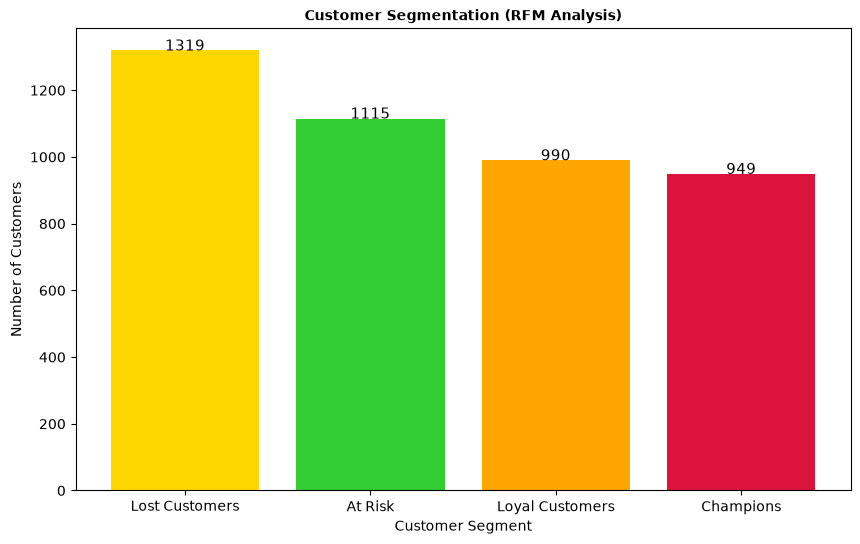

In [22]:
# Step 6: Customer Segment Bar Chart
segment_counts = (
    rfm['Segment']
    .value_counts()
)

plt.figure(figsize=(10,6))

colors = ['gold', 'limegreen', 'orange', 'crimson']

bars = plt.bar(
    segment_counts.index,
    segment_counts.values,
    color=colors
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center',
        fontsize=11
    )

plt.title(
    'Customer Segmentation (RFM Analysis)',
    fontsize=10,
    fontweight='bold'
)

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.show()

<b> Business Insights </b><br>

After running the analysis, write insights similar to: <br>

<b> Champions </b><br> 
Recent purchasers with high order frequency and high spending.<br>
Ideal customers for VIP rewards and referral programs.<br>

<b> Loyal Customers</b><br>
Purchase regularly and contribute significant revenue.<br>
Can be nurtured with loyalty campaigns.<br>

<b>At-Risk Customers</b><br>
Previously active customers who have not purchased recently.<br>
Target with win-back promotions and personalized offers.<br>

<b>Lost Customers</b><br>
Long inactive customers with low engagement.<br>
Re-engagement campaigns may have limited ROI.<br>
<b>Business Recommendation</b><br>

Focus retention efforts on At-Risk customers before they become Lost.<br>
Reward Champions to increase customer lifetime value.<br>
Use targeted marketing rather than one-size-fits-all campaigns.<br>

This is exactly the type of analysis hiring managers and freelance clients expect when they see Customer Analytics / RFM Segmentation on a portfolio project.

In [23]:
plt.rcParams.update({
    "figure.dpi": 130,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = {
    "primary": "#4F46E5",
    "accent":  "#F59E0B",
    "danger":  "#EF4444",
    "success": "#10B981",
    "muted":   "#94A3B8",
}

<b> Q5.What percentage of revenue comes from repeat customers versus one-time buyers?</b><br>

**Business problem:**  
If one-time buyers dominate, retention strategy must be prioritised over acquisition spending.

CustomerType  TotalPrice  Percentage
    One-Time  433784.671        4.45
      Repeat 9313963.263       95.55


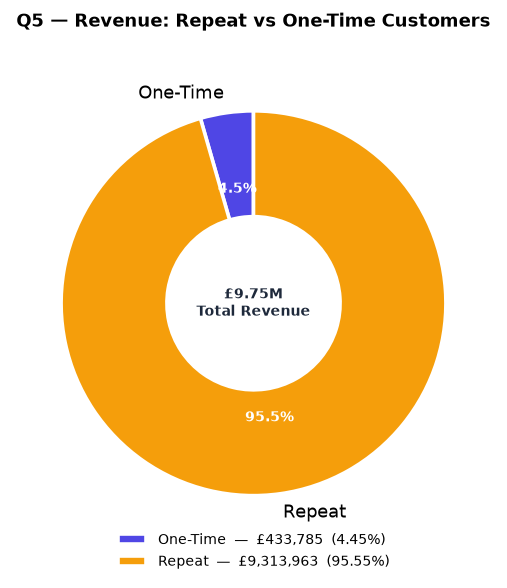

In [33]:
orders_per_customer = (
    data.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .reset_index()                                      
    .rename(columns={"InvoiceNo": "OrderCount"})       
)

orders_per_customer["CustomerType"] = np.where(
    orders_per_customer["OrderCount"] > 1, "Repeat", "One-Time"
)

revenue_per_customer = (
    data.groupby("CustomerID")["TotalPrice"]
    .sum()
    .reset_index()
)

merged = orders_per_customer.merge(revenue_per_customer, on="CustomerID")
revenue_split = (
    merged.groupby("CustomerType")["TotalPrice"]
    .sum()
    .reset_index()
)
revenue_split["Percentage"] = (
    revenue_split["TotalPrice"] / revenue_split["TotalPrice"].sum() * 100
).round(2)

print(revenue_split.to_string(index=False))



# ── Donut chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 5))
colors = [PALETTE["primary"], PALETTE["accent"]]
wedges, texts, autotexts = ax.pie(
    revenue_split["TotalPrice"],
    labels=revenue_split["CustomerType"],
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_fontweight("bold")
    at.set_color("white")

total_rev = revenue_split["TotalPrice"].sum()
ax.text(0, 0, f"£{total_rev/1e6:.2f}M\nTotal Revenue",
        ha="center", va="center", fontsize=8, fontweight="bold", color="#1E293B")

ax.set_title("Q5 — Revenue: Repeat vs One-Time Customers",
             fontsize=10, fontweight="bold", pad=20)

legend_labels = [
    f"{row.CustomerType}  —  £{row.TotalPrice:,.0f}  ({row.Percentage}%)"
    for _, row in revenue_split.iterrows()
]
ax.legend(wedges, legend_labels, loc="lower center",
          bbox_to_anchor=(0.5, -0.08), fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


**Q6. How does customer retention change month over month which cohort has the best long-term retention?**

**Business context:**
Cohort analysis shows whether product or service improvements are actually keeping customers longer over time.

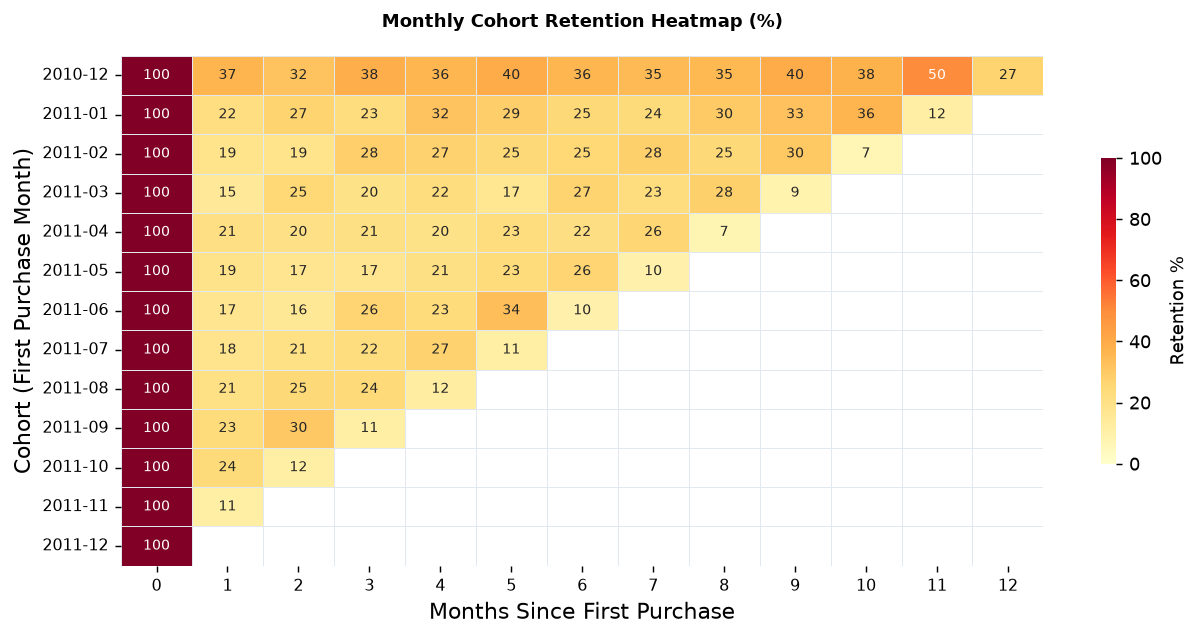

In [46]:
cohort_df = data[data["Quantity"] > 0].copy()
cohort_df["InvoiceDate"] = pd.to_datetime(cohort_df["InvoiceDate"])
cohort_df["OrderMonth"] = cohort_df["InvoiceDate"].dt.to_period("M")

cohort_df["CohortMonth"] = (
    cohort_df.groupby("CustomerID")["OrderMonth"]
    .transform("min")
)

cohort_df["CohortIndex"] = (
    cohort_df["OrderMonth"].dt.year  * 12 + cohort_df["OrderMonth"].dt.month
) - (
    cohort_df["CohortMonth"].dt.year * 12 + cohort_df["CohortMonth"].dt.month
)

cohort_counts = (
    cohort_df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_counts.pivot(
    index="CohortMonth", columns="CohortIndex", values="CustomerID"
)

cohort_size = cohort_pivot.iloc[:, 0]
retention   = cohort_pivot.divide(cohort_size, axis=0) * 100
retention   = retention.round(1)




fig, ax = plt.subplots(figsize=(10, 5))
mask = retention.isna()

sns.heatmap(
    retention,
    mask=mask,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="#E2E8F0",
    ax=ax,
    cbar_kws={"label": "Retention %", "shrink": 0.6},
    annot_kws={"size": 7.5},
    vmin=0, vmax=100,
)
ax.set_title("Monthly Cohort Retention Heatmap (%)",
             fontsize=10, fontweight="bold", pad=16)
ax.set_xlabel("Months Since First Purchase", fontsize=12)
ax.set_ylabel("Cohort (First Purchase Month)", fontsize=12)
ax.tick_params(axis="x", labelsize=9)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

**Area 3 Orders & Operations**

**Q7. What is the average order value (AOV), and how has it trended over time?**

**Business context:**  
A rising AOV suggests upselling is working; a declining AOV is a warning sign for pricing strategy or basket size.


  Overall AOV: £513.54
YearMonthStr        AOV
     2010-12 505.675961
     2011-01 617.289786
     2011-02 465.037202
     2011-03 468.738968
     2011-04 408.049030
     2011-05 445.139237
     2011-06 483.337500
     2011-07 467.026747
     2011-08 523.076125
     2011-09 558.328150
     2011-10 542.498497
     2011-11 523.403721
     2011-12 761.373874


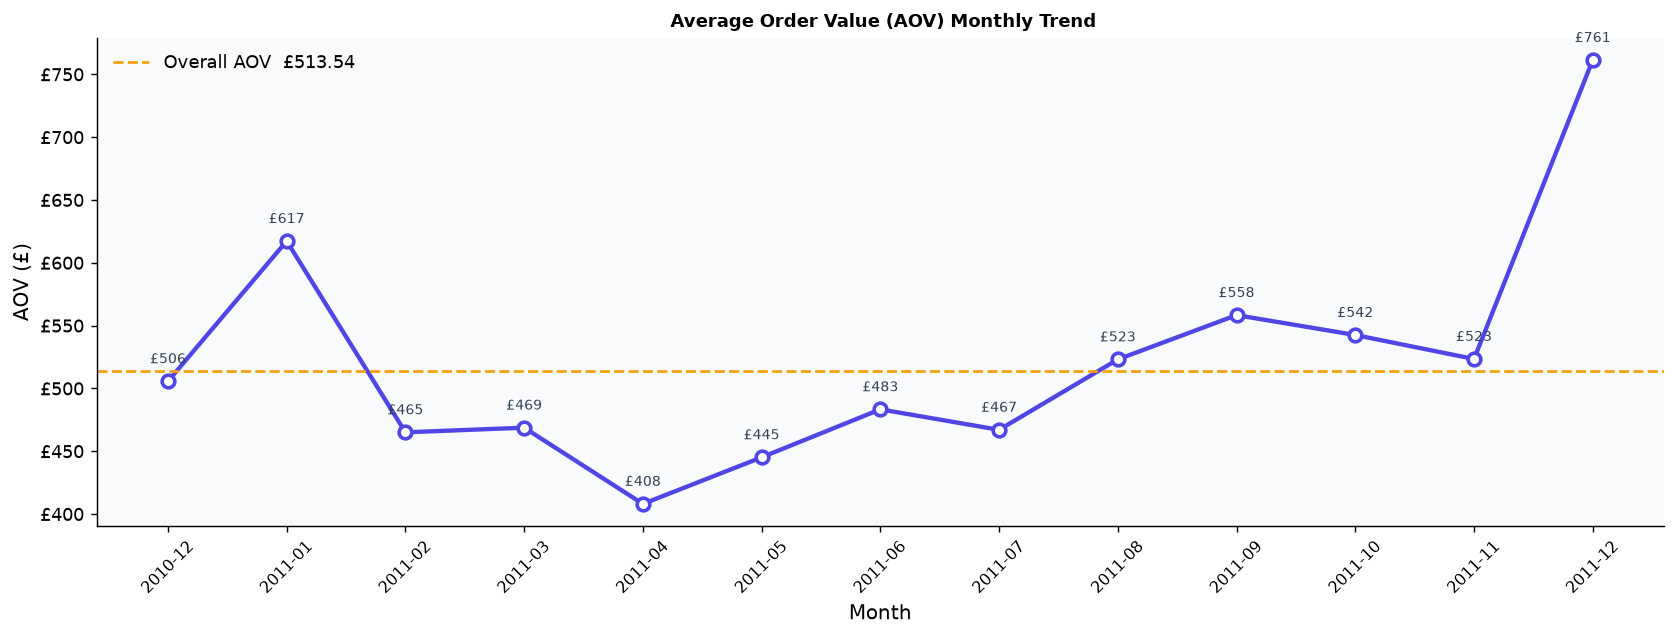

In [ ]:
aov_df = data[data["Quantity"] > 0].copy()

invoice_totals = (
    aov_df.groupby(["InvoiceNo", "YearMonth"])["TotalPrice"]
    .sum()
    .reset_index()
)
invoice_totals.columns = ["InvoiceNo", "YearMonth", "InvoiceTotal"]

monthly_aov = (
    invoice_totals.groupby("YearMonth")["InvoiceTotal"]
    .mean()
    .reset_index()
)
monthly_aov.columns = ["YearMonth", "AOV"]
monthly_aov = monthly_aov.sort_values("YearMonth")
monthly_aov["YearMonthStr"] = monthly_aov["YearMonth"].astype(str)

overall_aov = invoice_totals["InvoiceTotal"].mean()
print(f"  Overall AOV: £{overall_aov:.2f}")
print(monthly_aov[["YearMonthStr", "AOV"]].to_string(index=False))


# Chart
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly_aov["YearMonthStr"], monthly_aov["AOV"],
        marker="o", linewidth=2.4, color=PALETTE["primary"],
        markerfacecolor="white", markeredgewidth=2, markersize=7)

ax.axhline(overall_aov, color=PALETTE["accent"], linestyle="--",
           linewidth=1.5, label=f"Overall AOV  £{overall_aov:.2f}")

for _, row in monthly_aov.iterrows():
    ax.annotate(f"£{row.AOV:.0f}",
                xy=(row.YearMonthStr, row.AOV),
                xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=8, color="#334155")

ax.set_title(" Average Order Value (AOV) Monthly Trend",
             fontsize=10, fontweight="bold")

ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("AOV (£)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.legend(fontsize=10, frameon=False)
ax.set_facecolor("#F8FAFC")
plt.tight_layout()
plt.savefig("q7_aov_trend.png", bbox_inches="tight")
plt.show()


**Q8. What proportion of transactions are returns (negative quantities), and which products have the highest return rate?**

**Business context:**  
High return rates on specific products signal quality issues or misleading product descriptions that need fixing.


                       Description  TotalTransactions  ReturnTransactions  ReturnRate
                             check                 43                 126      293.02
                            Manual                345                 257       74.49
            CINDERELLA CHANDELIER                  23                  11       47.83
          ROCOCO WALL MIRROR WHITE                 45                  13       28.89
      VINTAGE BLUE KITCHEN CABINET                 21                   6       28.57
       WHITE TEA,COFFEE,SUGAR JARS                 60                  17       28.33
              SAVOY ART DECO CLOCK                 53                  13       24.53
       RETRO PLASTIC ELEPHANT TRAY                 65                  14       21.54
       VINTAGE RED KITCHEN CABINET                 38                   8       21.05
   SET OF 3 COLOURED  FLYING DUCKS                 39                   8       20.51
             LARGE POPCORN HOLDER                  86 

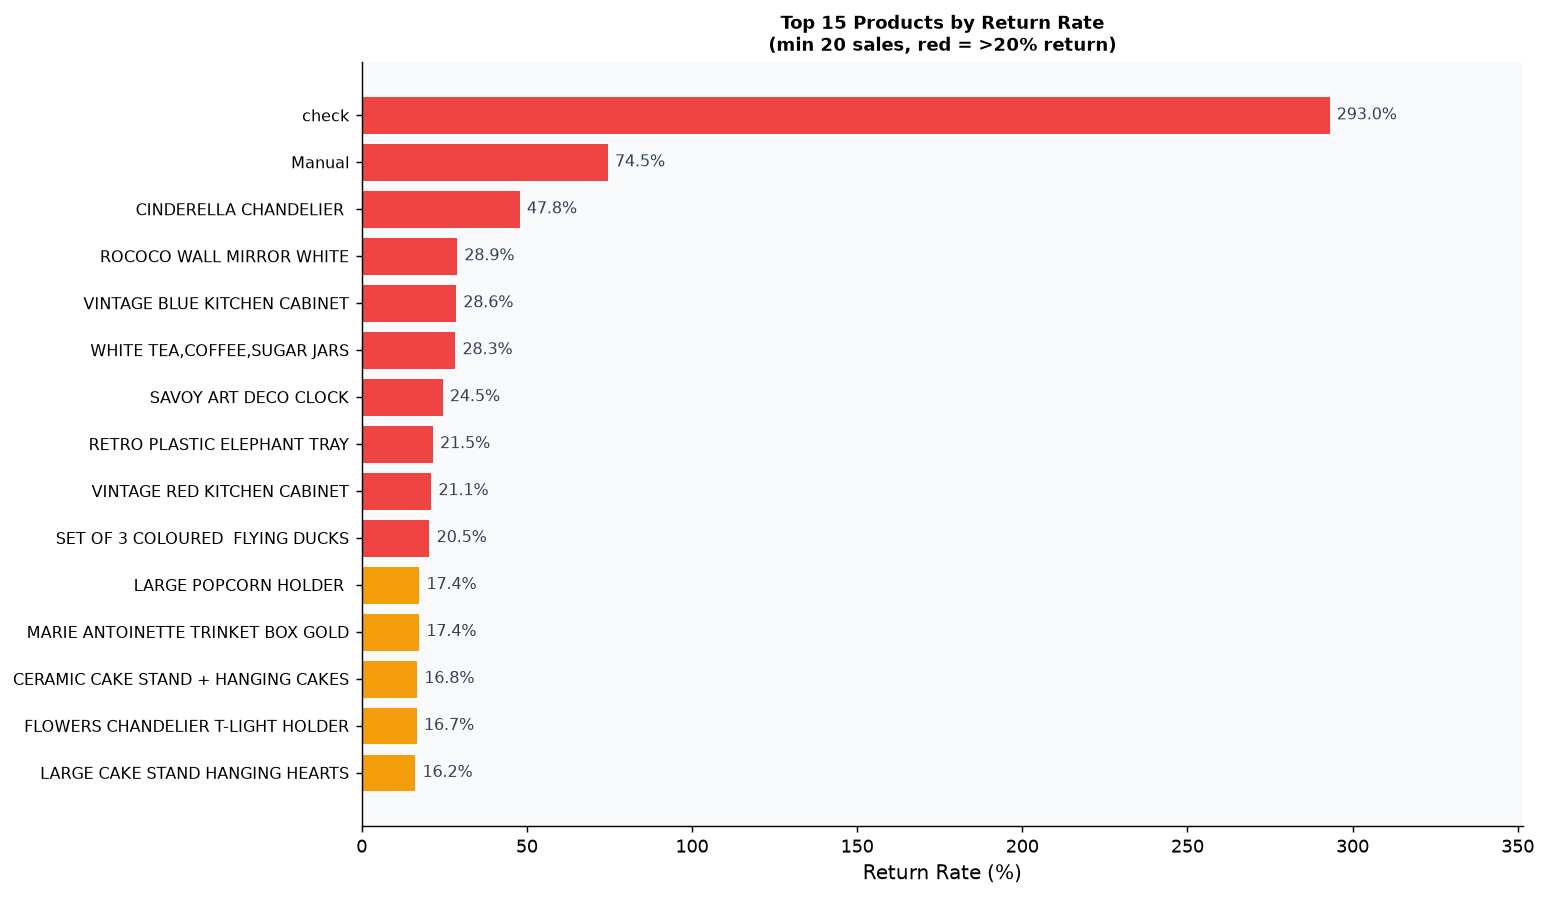

In [50]:
returns_df = data[data["Quantity"] < 0].copy()
sales_df   = data[data["Quantity"] > 0].copy()

total_tx_per_product = (
    sales_df.groupby("Description")["InvoiceNo"]
    .count()
    .reset_index()
    .rename(columns={"InvoiceNo": "TotalTransactions"})
)
return_tx_per_product = (
    returns_df.groupby("Description")["InvoiceNo"]
    .count()
    .reset_index()
    .rename(columns={"InvoiceNo": "ReturnTransactions"})
)

return_analysis = total_tx_per_product.merge(
    return_tx_per_product, on="Description", how="left"
).fillna(0)

return_analysis["ReturnTransactions"] = return_analysis["ReturnTransactions"].astype(int)
return_analysis["ReturnRate"] = (
    return_analysis["ReturnTransactions"] / return_analysis["TotalTransactions"] * 100
).round(2)

min_sales = 20
top_returns = (
    return_analysis[return_analysis["TotalTransactions"] >= min_sales]
    .sort_values("ReturnRate", ascending=False)
    .head(15)
)

print(top_returns[["Description", "TotalTransactions",
                    "ReturnTransactions", "ReturnRate"]].to_string(index=False))


# Chart
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top_returns["Description"].str[:45],
    top_returns["ReturnRate"],
    color=[PALETTE["danger"] if r > 20 else PALETTE["accent"]
           for r in top_returns["ReturnRate"]],
    edgecolor="white", linewidth=0.5,
)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9, color="#334155")
ax.invert_yaxis()
ax.set_title("Top 15 Products by Return Rate\n(min 20 sales, red = >20% return)",
             fontsize=10, fontweight="bold")
ax.set_xlabel("Return Rate (%)", fontsize=11)
ax.set_xlim(0, top_returns["ReturnRate"].max() * 1.2)
ax.tick_params(axis="y", labelsize=9)
ax.set_facecolor("#F8FAFC")
plt.tight_layout()
plt.savefig("q8_return_rate.png", bbox_inches="tight")
plt.show()

**Area 4 Time & Demand Patterns**

**Q9. Which day of the week and hour of the day sees the most orders placed?**

**Business context:**  
Helps schedule customer support, email campaigns, and flash sales at peak engagement windows for maximum impact.

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
Hour       6   7    8    9    10   11   12   13   14   15   16   17   18   19  20
DayOfWeek                                                                        
Monday      0   4   89  279  367  370  512  459  420  383  253   99    2    0   0
Tuesday     0   5  119  331  430  446  584  518  447  476  219  131   11    0   0
Wednesday   0   5  117  311  457  459  648  519  471  458  287  119   11    2   1
Thursday    1   9  122  316  478  395  605  514  481  492  368  294  183  135  16
Friday      0   6  121  299  472  413  512  446  428  325  165   95    2    9   1
Saturday    0   0    0    0    0    0    0    0    0    0    0    0    0    0   0
Sunday      0   0    0    2  227  390  462  362  310  340  114    0    0    0   0


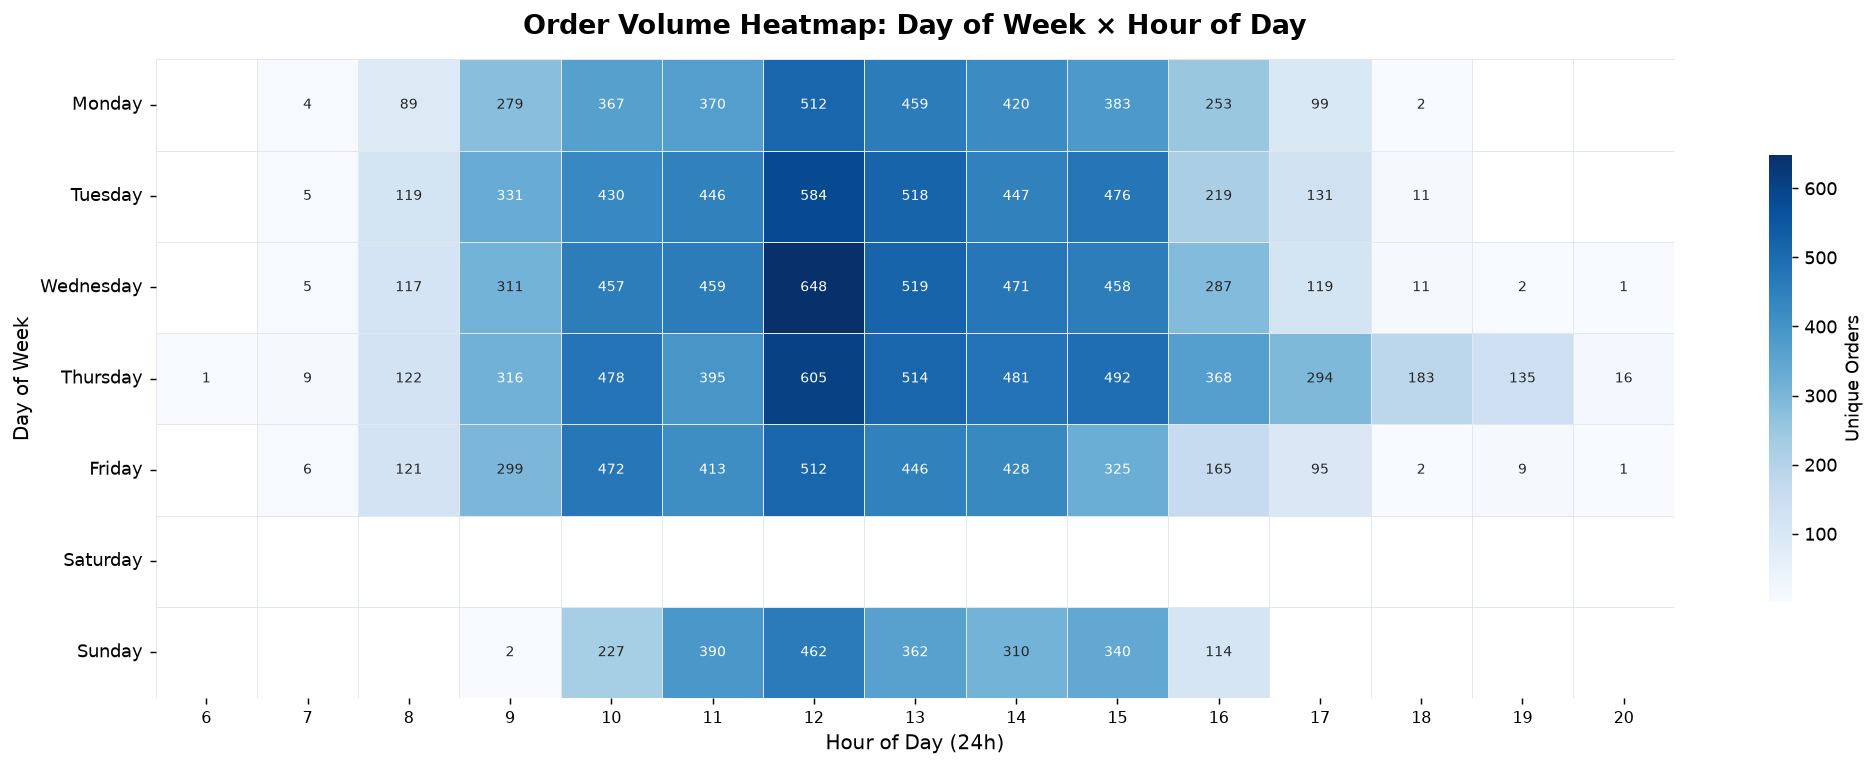

In [ ]:
time_df = data[data["Quantity"] > 0].copy()
time_df["InvoiceDate"] = pd.to_datetime(time_df["InvoiceDate"])
time_df["DayOfWeek"]   = time_df["InvoiceDate"].dt.day_name()
time_df["Hour"]        = time_df["InvoiceDate"].dt.hour

day_hour = (
    time_df.groupby(["DayOfWeek", "Hour"])["InvoiceNo"]
    .nunique()
    .reset_index()
    .rename(columns={"InvoiceNo": "Orders"})
)

day_order  = ["Monday", "Tuesday", "Wednesday", "Thursday",
              "Friday", "Saturday", "Sunday"]
pivot_time = day_hour.pivot(index="DayOfWeek", columns="Hour", values="Orders")
pivot_time = pivot_time.reindex(day_order)

print(pivot_time.fillna(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_time,
    cmap="Blues",
    linewidths=0.3,
    linecolor="#E2E8F0",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 8},
    ax=ax,
    cbar_kws={"label": "Unique Orders", "shrink": 0.7},
)
ax.set_title("Order Volume Heatmap: Day of Week × Hour of Day",
             fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Hour of Day (24h)", fontsize=11)
ax.set_ylabel("Day of Week", fontsize=11)
ax.tick_params(axis="y", rotation=0, labelsize=10)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.savefig("q9_day_hour_heatmap.png", bbox_inches="tight")
plt.show()

**Q10. Which products are frequently bought together in the same invoice?**

**Business context:**  
Market basket insight enables "frequently bought together" recommendations, directly increasing average order value.

  Frequent itemsets found: 360

  Top 20 Association Rules (by Lift):


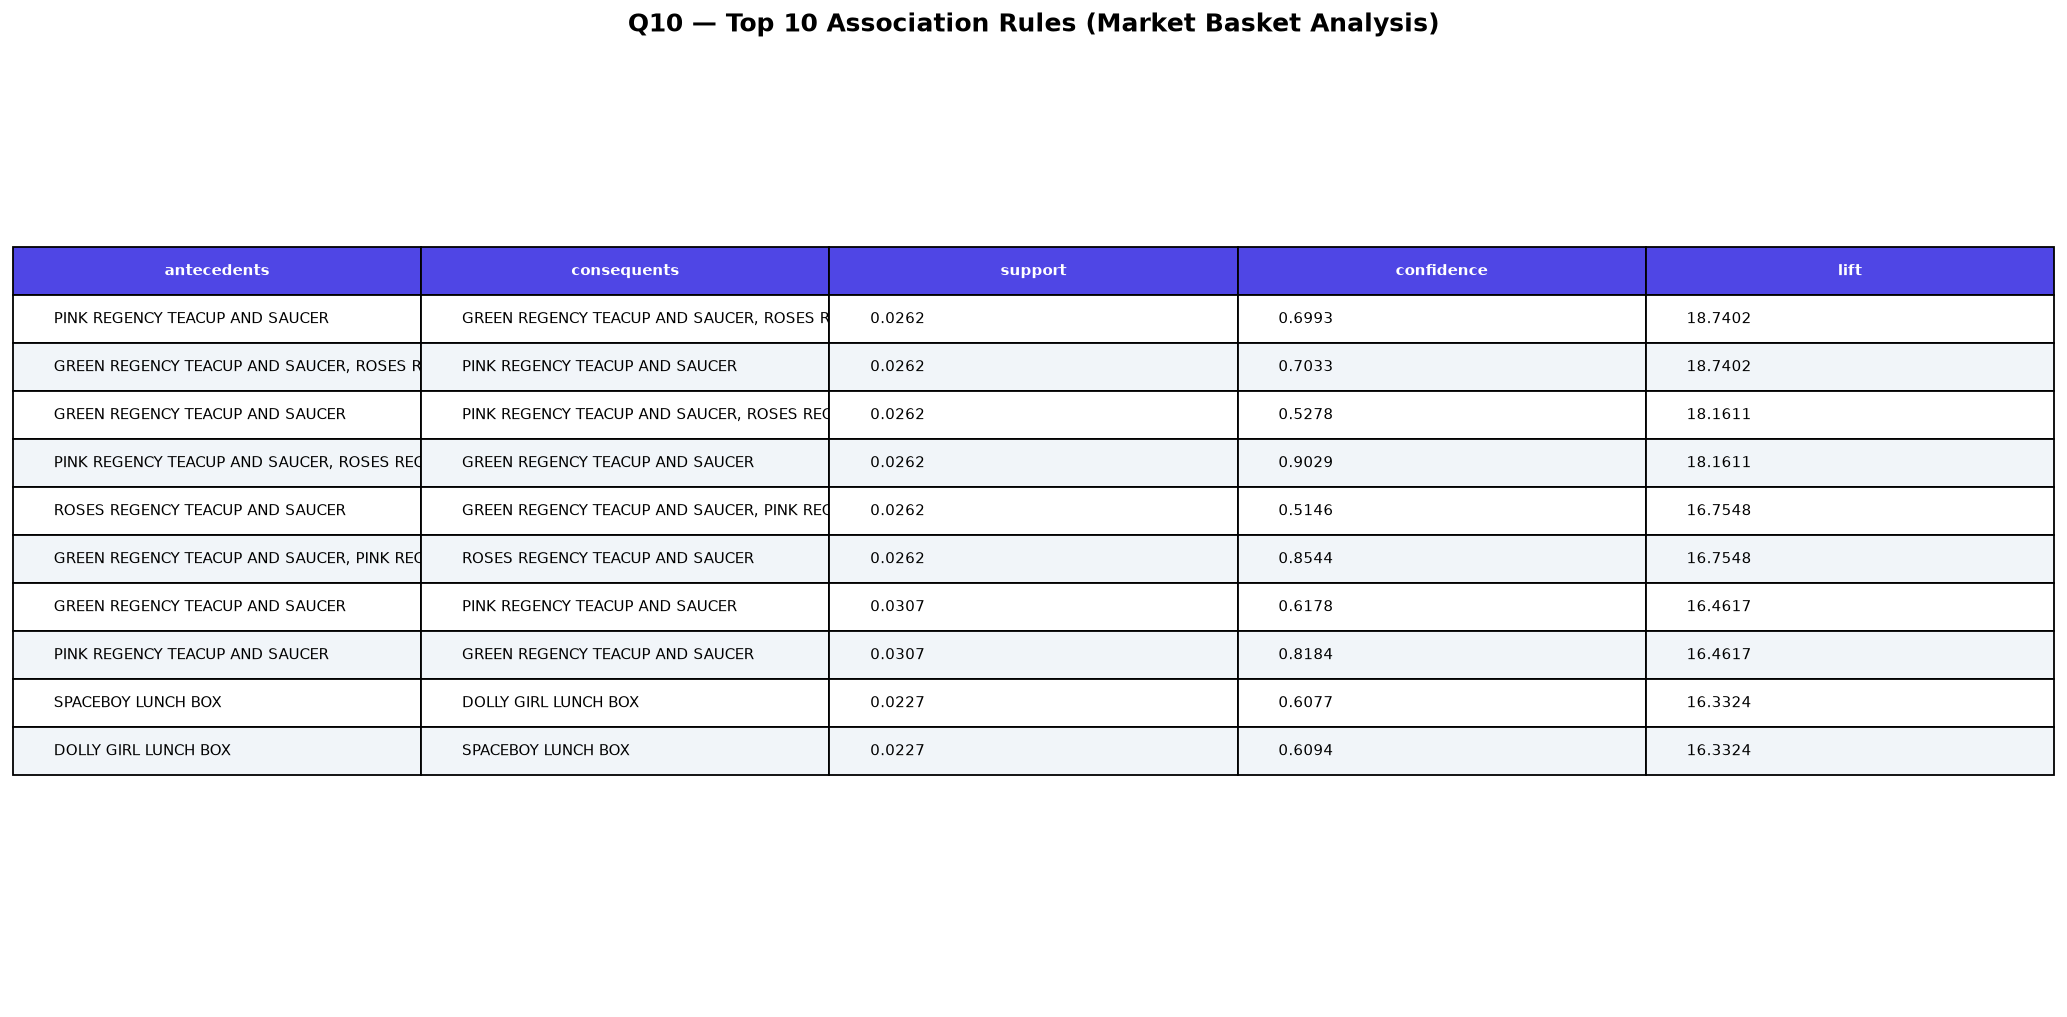


  Building network graph for top rules...


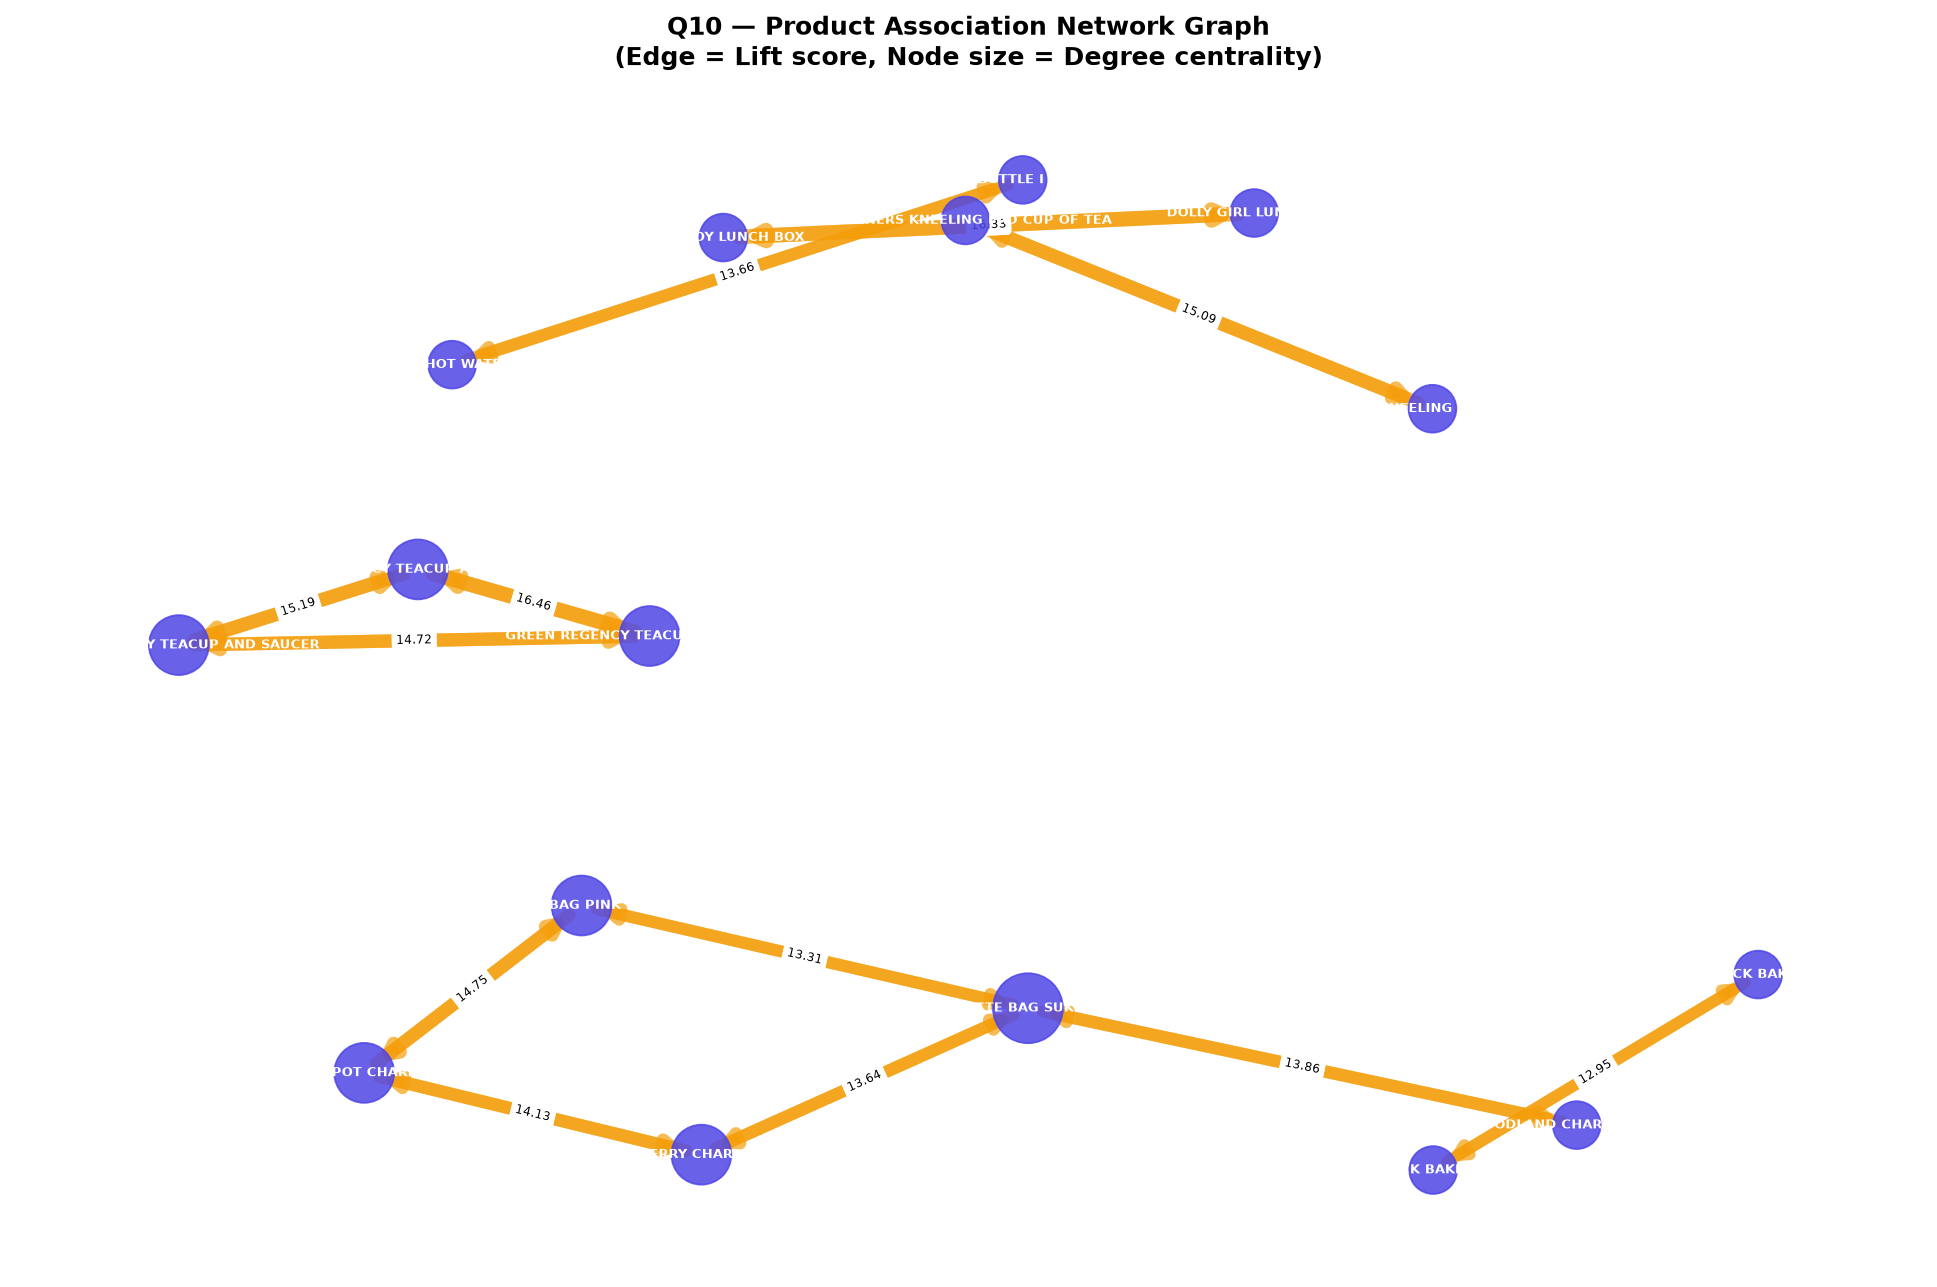

In [ ]:

basket_df = data[data["Quantity"] > 0].copy()
basket_df = basket_df[basket_df["Country"] == "United Kingdom"]

basket = (
    basket_df.groupby(["InvoiceNo", "Description"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
    .reset_index(drop=True)
)

basket_encoded = basket.apply(lambda col: col > 0)   # clean boolean encoding

frequent_itemsets = apriori(
    basket_encoded,
    min_support=0.02,
    use_colnames=True,
    max_len=3,
)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
print(f"  Frequent itemsets found: {len(frequent_itemsets)}")

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.5,
    num_itemsets=len(frequent_itemsets),   # ← required in newer mlxtend
)
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

rules_display = rules[["antecedents", "consequents",
                        "support", "confidence", "lift"]].head(20).copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(list(x)))
rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(list(x)))
rules_display[["support", "confidence", "lift"]] = (
    rules_display[["support", "confidence", "lift"]].round(4)
)

print("\n  Top 20 Association Rules (by Lift):")
print(rules_display.to_string(index=False))


# ── Table chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis("off")
top10 = rules_display.head(10)
table = ax.table(
    cellText=top10.values,
    colLabels=top10.columns,
    cellLoc="left",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1, 1.8)

for j in range(len(top10.columns)):
    table[0, j].set_facecolor(PALETTE["primary"])
    table[0, j].set_text_props(color="white", fontweight="bold")
for i in range(1, len(top10) + 1):
    for j in range(len(top10.columns)):
        table[i, j].set_facecolor("#F1F5F9" if i % 2 == 0 else "white")

ax.set_title("Q10 — Top 10 Association Rules (Market Basket Analysis)",
             fontsize=14, fontweight="bold", pad=20, y=0.95)
plt.tight_layout()
plt.savefig("q10_association_rules_table.png", bbox_inches="tight")
plt.show()

# ── Network Graph ─────────────────────────────────────────────
print("\n  Building network graph for top rules...")
top_rules_net = rules.head(30)

G = nx.DiGraph()
for _, row in top_rules_net.iterrows():
    for ant in row["antecedents"]:
        for con in row["consequents"]:
            G.add_edge(ant, con, weight=round(row["lift"], 2))

fig, ax = plt.subplots(figsize=(15, 10))
pos          = nx.spring_layout(G, seed=42, k=2)
edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
node_degree  = dict(G.degree())
node_sizes   = [300 + node_degree[n] * 200 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                       node_color=PALETTE["primary"], alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white",
                        font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, width=[w * 0.5 for w in edge_weights],
                       edge_color=PALETTE["accent"], alpha=0.7,
                       arrows=True, arrowsize=15, ax=ax)
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                             font_size=6.5, ax=ax)

ax.set_title("Q10 — Product Association Network Graph\n"
             "(Edge = Lift score, Node size = Degree centrality)",
             fontsize=14, fontweight="bold")
ax.axis("off")
ax.set_facecolor("#F8FAFC")
plt.tight_layout()
plt.savefig("q10_network_graph.png", bbox_inches="tight")
plt.show()

## Insights Summary

- Problem: The e-commerce business needed visibility into revenue trends and seasonal patterns.  
  Result: Monthly revenue analysis identified peak sales periods and clear seasonality for better planning.

- Problem: It was unclear which products were strong sellers or underperformers.  
  Result: Product revenue ranking highlighted top revenue drivers and low-performing SKU groups.

- Problem: Customer loyalty and churn risk were not measured.  
  Result: RFM segmentation revealed high-value customers and at-risk segments for targeted retention campaigns.

- Problem: The business did not know how much revenue came from repeat customers.  
  Result: Repeat buyer analysis showed the contribution of loyal customers and the opportunity to improve retention.

- Problem: Operational issues such as returns and peak order times were not quantified.  
  Result: Return rate and demand pattern analysis exposed products with high return risk and the best time windows for marketing and support.

- Problem: Cross-sell opportunities were not identified.  
  Result: Market basket analysis produced association rules and product pairings to support "frequently bought together" recommendations.

This notebook delivers actionable insights for revenue growth, customer retention, and operational improvements.

## Key Recommendations

- Focus on high-revenue product groups while investigating low-performing SKUs for markdowns or bundle offers.
- Prioritise retention campaigns for At-Risk customers and reward Champions to increase lifetime value.
- Use repeat-customer revenue analysis to shift budget toward customer loyalty rather than only new acquisition.
- Address products with high return rates by improving product descriptions, quality checks, and return policy communication.
- Schedule marketing promotions and customer support during peak order windows identified in the day/hour demand analysis.